# 01 · Datos, calendario y calidad de las noticias

**Pregunta:** ¿qué datos alimentan la comparación y qué limitaciones debemos tener presentes?

Este cuaderno explora el panel corregido de AAPL, MSFT, NVDA y TSLA. SPY no participa en el entrenamiento. No descarga noticias, no usa claves y no entrena modelos.

## Recorrido
1. Identificar la ejecución y cargar sus datos.
2. Comprobar dimensiones, claves, etiqueta y variables.
3. Entender el periodo, el balance de clases y la cobertura.
4. Verificar las fronteras temporales y extraer conclusiones.

**Preparación:** instalar `requirements.txt` y ejecutar las celdas en orden, desde la raíz del repositorio o desde `notebooks/`. Si falta el dataset local de ejecución, se reconstruye en un directorio temporal a partir de los datos guardados, reutilizando `src/data/point_in_time.py`. Si faltan esas entradas, se indica cuáles son; nunca se inicia una descarga automática.

## 1. Ejecución y procedencia

Se fija un identificador explícito. No se elige automáticamente la carpeta más reciente, porque podría ser una prueba técnica o un experimento diferente.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src").is_dir() and (p / "reports").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Abre el notebook desde la raíz del proyecto o desde notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RUN_ID = "review-full-20260908"
RUN = ROOT / "reports" / "experiments" / RUN_ID
manifest = json.loads((RUN / "manifest.json").read_text(encoding="utf-8"))
assert manifest["status"] == "complete", "La ejecución seleccionada no está completa."
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110, "font.size": 10})
pd.set_option("display.max_columns", 12)
display(Markdown(f"**Ejecución seleccionada:** `{RUN_ID}`. Histórico exploratorio, no holdout independiente."))

**Ejecución seleccionada:** `review-full-20260908`. Histórico exploratorio, no holdout independiente.

In [2]:
from tempfile import TemporaryDirectory
from src.data.point_in_time import build_dataset
from src.experiments.artifacts import sha256
from src.data.split_train_test import FINANCIAL_FEATURES, SENTIMENT_FEATURES

cached_dataset = ROOT / manifest["artifact_paths"]["data"] / "dataset.csv"
# Cambiar a True permite comprobar la reconstrucción sin usar la copia local.
REBUILD_DATASET = False

if cached_dataset.exists() and not REBUILD_DATASET:
    dataset = pd.read_csv(cached_dataset, parse_dates=["Date", "target_end"])
    origin = "Dataset conservado de la ejecución"
else:
    required = [(ROOT / name.replace(chr(92), '/'), digest) for name, digest in manifest["input_sha256"].items()]
    missing = [str(path.relative_to(ROOT)) for path, _ in required if not path.exists()]
    if missing:
        raise FileNotFoundError("Faltan entradas guardadas: " + ", ".join(missing))
    changed = [str(path.relative_to(ROOT)) for path, digest in required if sha256(path) != digest]
    if changed:
        display(Markdown("**Aviso:** hay entradas distintas del manifiesto. La reconstrucción no representa exactamente el experimento original."))
    with TemporaryDirectory() as directory:
        dataset, _, _ = build_dataset(ROOT, Path(directory), manifest["config"]["source_timezone"])
    origin = "Reconstrucción temporal con el código actual"

display(Markdown(f"**Procedencia:** {origin}. Las copias reconstruidas no reemplazan datos del proyecto."))
summary = dataset.groupby("ticker").agg(
    filas=("Date", "size"), inicio=("Date", "min"), fin=("Date", "max"),
    subidas=("target", "sum"), proporcion_subidas=("target", "mean"),
)
display(summary.style.format({"proporcion_subidas": "{:.2%}", "inicio": "{:%Y-%m-%d}", "fin": "{:%Y-%m-%d}"}))

**Procedencia:** Dataset conservado de la ejecución. Las copias reconstruidas no reemplazan datos del proyecto.

,filas,inicio,fin,subidas,proporcion_subidas
ticker,,,,,
AAPL,2764,2015-01-02,2025-12-29,1470,53.18%
MSFT,2764,2015-01-02,2025-12-29,1480,53.55%
NVDA,2764,2015-01-02,2025-12-29,1506,54.49%
TSLA,2764,2015-01-02,2025-12-29,1429,51.70%


## 2. Contratos de calidad

Cada fila corresponde a una empresa y una sesión. La clase 1 significa que el cierre ajustado de la sesión siguiente es mayor; la clase 0 incluye caída o igualdad. `target_end` indica cuándo se conoce la etiqueta.

Las comprobaciones siguientes detectan duplicados, nulos y horizontes inválidos. Que pasen no certifica exhaustividad del proveedor ni disponibilidad real del sentimiento en tiempo real.

In [3]:
checks = pd.Series({
    "Claves empresa-fecha únicas": not dataset.duplicated(["ticker", "Date"]).any(),
    "Solo las cuatro empresas del estudio": set(dataset["ticker"]) == {"AAPL", "MSFT", "NVDA", "TSLA"},
    "Objetivo binario y completo": dataset["target"].isin([0, 1]).all(),
    "Horizonte posterior a la observación": (dataset["target_end"] > dataset["Date"]).all(),
    "Predictores finitos": np.isfinite(dataset[FINANCIAL_FEATURES + SENTIMENT_FEATURES].to_numpy(dtype=float)).all(),
})
display(checks.rename("Correcto").to_frame())
assert checks.all(), "Revisar los controles fallidos antes de interpretar resultados."
feature_counts = pd.DataFrame([
    {"variante": name, "predictores": len(columns)}
    for name, columns in manifest["feature_sets"].items()
])
display(feature_counts)

,Correcto
Claves empresa-fecha únicas,True
Solo las cuatro empresas del estudio,True
Objetivo binario y completo,True
Horizonte posterior a la observación,True
Predictores finitos,True


,variante,predictores
0,base,14
1,news_volume,16
2,sentiment_only,8
3,financial_sentiment,22
4,hybrid,27
5,lag_1,29
6,lag_2,29
7,lag_3,29
8,rolling_3,29
9,rolling_5,29


**Lectura:** el base tiene 14 variables y el híbrido 27. `sentiment_only` incluye proporciones y presencia de noticias, no únicamente puntuaciones de tono. Los retardos controlados tienen 29 variables; son distintos del ensayo histórico que añadió 65 variables y llegó a 92.

## 3. Precios y objetivo

La normalización a base 100 permite comparar trayectorias con escalas diferentes. Es descriptiva, no una simulación de inversión ni un predictor calculado con información futura.

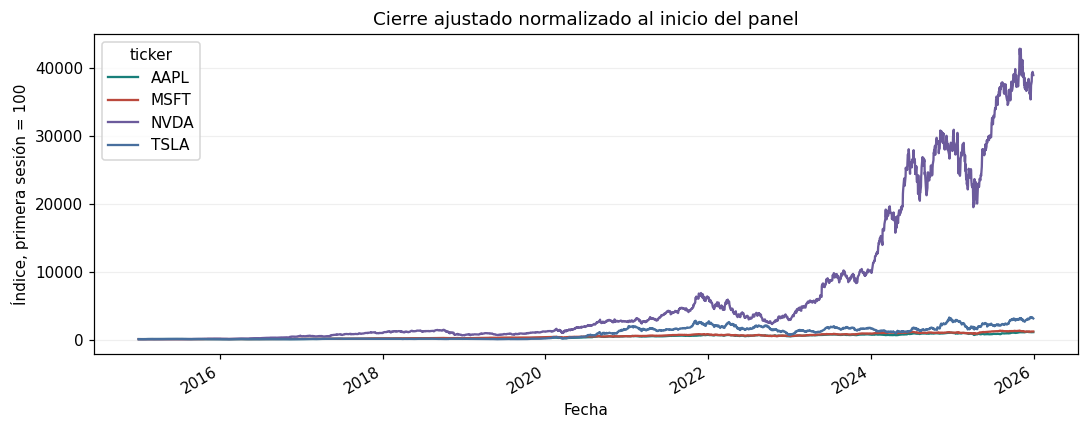

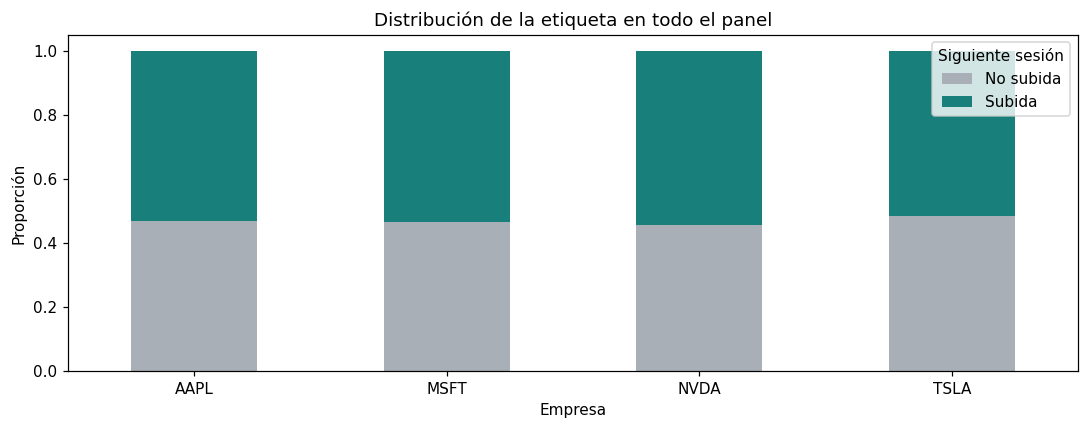

In [4]:
prices = dataset.pivot(index="Date", columns="ticker", values="Adj Close").sort_index()
normalized = prices.div(prices.iloc[0]).mul(100)
ax = normalized.plot(color=["#187f7a", "#bb493d", "#6c5b9c", "#486f9e"])
ax.set(title="Cierre ajustado normalizado al inicio del panel", xlabel="Fecha", ylabel="Índice, primera sesión = 100")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

class_balance = pd.crosstab(dataset["ticker"], dataset["target"], normalize="index").rename(columns={0: "No subida", 1: "Subida"})
ax = class_balance.plot.bar(stacked=True, color=["#a9afb6", "#187f7a"], rot=0)
ax.set(title="Distribución de la etiqueta en todo el panel", xlabel="Empresa", ylabel="Proporción")
ax.legend(title="Siguiente sesión", loc="upper right")
plt.tight_layout()
plt.show()

**Interpretación:** el balance del panel completo no tiene por qué coincidir con el del periodo externo. Un baseline que siempre predice subida puede tener una accuracy superior al 50 % sin discriminar entre clases. El segundo notebook muestra ese caso en las predicciones externas.

## 4. Cobertura informativa

Se utiliza el informe de cobertura de la ejecución, no se infiere que un cero represente ausencia real de noticias. La cantidad de registros cambia notablemente entre años.

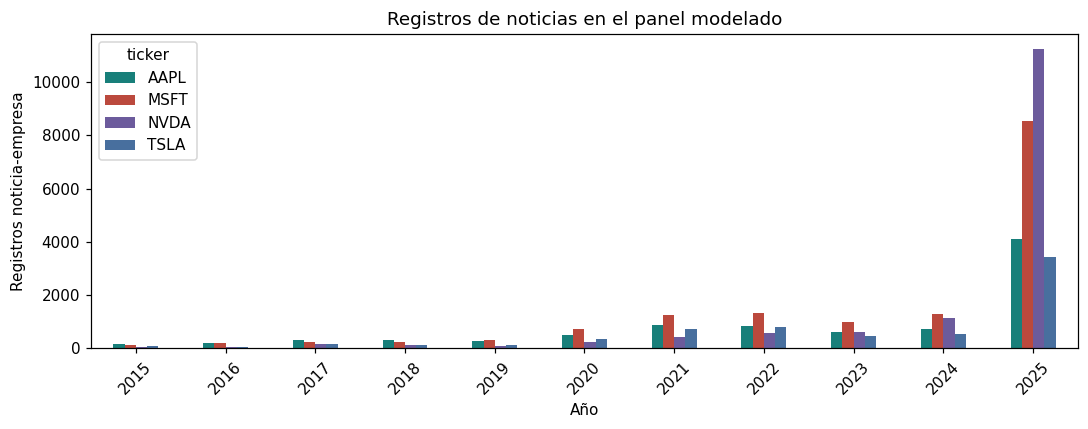

,noticias,sesiones_empresa,sesiones_con_noticias,proporcion_con_noticias
year,,,,
2015,414,1008,330,32.74%
2016,486,1008,340,33.73%
2017,850,1004,516,51.39%
2018,804,1004,475,47.31%
2019,859,1008,505,50.10%
2020,1835,1012,679,67.09%
2021,3307,1008,918,91.07%
2022,3538,1004,934,93.03%
2023,2666,1000,859,85.90%


,Auditoría del corpus alineado
news_rows,46014
exact_duplicates,0
repeated_titles_same_session,3124
assigned_later_date,17308
coverage_verified,False
absence_interpretation,No recorded news; provider completeness is unk...


In [5]:
coverage = pd.read_csv(RUN / "coverage" / "coverage_by_year_ticker.csv")
news_by_year = coverage.pivot(index="year", columns="ticker", values="recorded_news")
ax = news_by_year.plot.bar(color=["#187f7a", "#bb493d", "#6c5b9c", "#486f9e"], rot=45)
ax.set(title="Registros de noticias en el panel modelado", xlabel="Año", ylabel="Registros noticia-empresa")
plt.tight_layout()
plt.show()
display(coverage.groupby("year").agg(
    noticias=("recorded_news", "sum"),
    sesiones_empresa=("sessions", "sum"),
    sesiones_con_noticias=("recorded_news_days", "sum"),
).assign(proporcion_con_noticias=lambda df: df.sesiones_con_noticias / df.sesiones_empresa)
.style.format({"proporcion_con_noticias": "{:.2%}"}))
display(pd.Series(manifest["coverage"]).rename("Auditoría del corpus alineado").to_frame())

**Lectura:** los 46.014 registros alineados se refieren al calendario generado; los conteos por año de esta sección corresponden al panel modelado. No son necesariamente el mismo universo. Las 17.308 asignaciones a una fecha posterior incluyen fines de semana y publicaciones posteriores al cierre. `coverage_verified=False` impide afirmar que se descargaron todas las noticias existentes.

## 5. Días sin noticias y disponibilidad

Una noticia neutral tiene presencia informativa; un día sin registros se rellena con ceros y `has_news=False`. La asignación utiliza el primer cierre igual o posterior a la publicación. El timestamp sigue siendo una aproximación de disponibilidad, no la hora de recepción.

In [6]:
availability = dataset.groupby("ticker").agg(
    sesiones=("Date", "size"),
    sesiones_con_noticias=("has_news", "sum"),
    media_noticias=("news_count", "mean"),
)
availability["sin_noticias_registradas"] = 1 - availability["sesiones_con_noticias"] / availability["sesiones"]
display(availability.style.format({"media_noticias": "{:.2f}", "sin_noticias_registradas": "{:.2%}"}))

no_news = dataset.loc[~dataset["has_news"].astype(bool), SENTIMENT_FEATURES]
assert (no_news == 0).all().all(), "Una sesión sin noticias contiene valores de sentimiento no neutros."
example = dataset.loc[dataset["has_news"].astype(bool), ["ticker", "Date", "news_count", "sentiment_mean", "has_news"]].head(6)
display(example)

,sesiones,sesiones_con_noticias,media_noticias,sin_noticias_registradas
ticker,,,,
AAPL,2764,2060,3.22,25.47%
MSFT,2764,2152,5.52,22.14%
NVDA,2764,1552,5.32,43.85%
TSLA,2764,1716,2.50,37.92%


,ticker,Date,news_count,sentiment_mean,has_news
3,AAPL,2015-01-07,1,0.301637,True
4,AAPL,2015-01-08,2,0.020935,True
6,AAPL,2015-01-12,3,0.200425,True
9,AAPL,2015-01-15,1,-0.340083,True
10,AAPL,2015-01-16,1,0.329454,True
11,AAPL,2015-01-20,1,0.122122,True


## 6. Fronteras temporales

El entrenamiento debe terminar antes del bloque externo y sus etiquetas también deben conocerse antes de ese bloque. Esta segunda condición es la purga. Las empresas se mantienen juntas por fecha.

In [7]:
selection = pd.read_csv(RUN / "tuning" / "selected_params.csv")
date_columns = ["train_end", "train_target_end", "test_start", "test_end"]
selection[date_columns] = selection[date_columns].apply(pd.to_datetime)
assert (selection["train_target_end"] < selection["test_start"]).all()
folds = selection.groupby("outer_fold")[["train_rows", "test_rows", *date_columns]].first()
display(folds.style.format({name: "{:%Y-%m-%d}" for name in date_columns}))
assert folds["test_rows"].sum() == 2212

,train_rows,test_rows,train_end,train_target_end,test_start,test_end
outer_fold,,,,,,
1,8840,740,2023-10-12,2023-10-13,2023-10-16,2024-07-11
2,9580,736,2024-07-10,2024-07-11,2024-07-12,2025-04-04
3,10316,736,2025-04-03,2025-04-04,2025-04-07,2025-12-29


## 7. Conclusiones de la exploración

- El panel y las variantes mantienen un universo común de cuatro empresas.
- El objetivo y las fronteras son temporales; no se mezclan filas mediante un split aleatorio.
- La cobertura de noticias es desigual y no está certificada.
- Los controles técnicos no demuestran señal predictiva: esa cuestión requiere comparar predicciones e incertidumbre.

**Continuación:** [02 · Resultados y límites de la evidencia](02_model_results.ipynb). La explicación completa está en [el borrador de memoria](../docs/borrador_memoria.md).